11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9244 - loss: 0.2551 - val_accuracy: 0.9640 - val_loss: 0.1126
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9681 - loss: 0.1031 - val_accuracy: 0.9723 - val_loss: 0.0959
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9774 - loss: 0.0722 - val_accuracy: 0.9797 - val_loss: 0.0721
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9826 - loss: 0.0550 - val_accuracy: 0.9755 - val_loss: 0.0822
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9857 - loss: 0.0445 - val_accuracy: 0.9795 - val_loss: 0.0778
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9889 - loss: 0.0344 - val_accuracy: 0.9803 - val_loss: 0.0749
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9905 - loss: 0.0282 - val_accuracy: 0.9792 - val_loss: 0.0785
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9915 - loss: 0.0254 

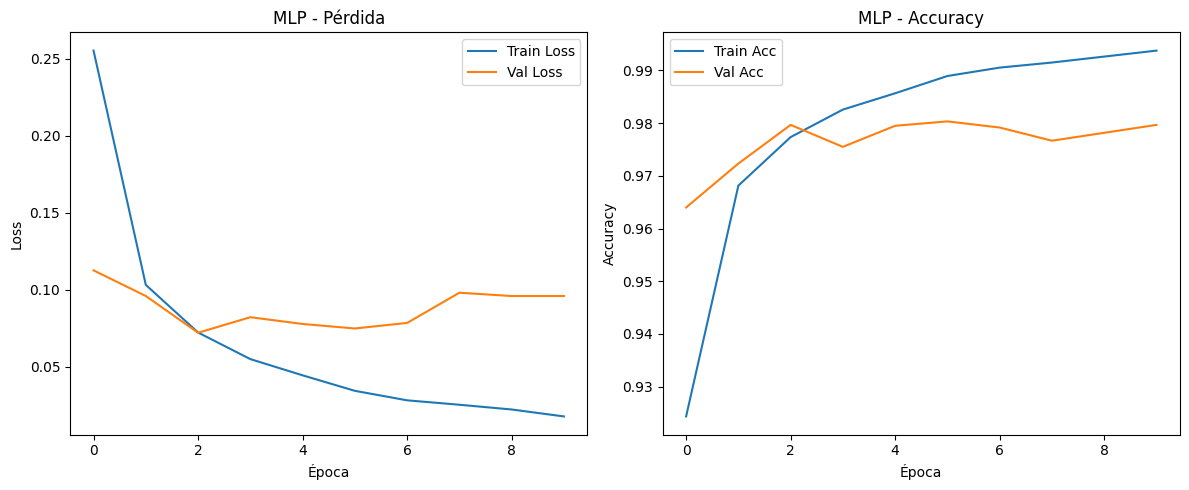

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


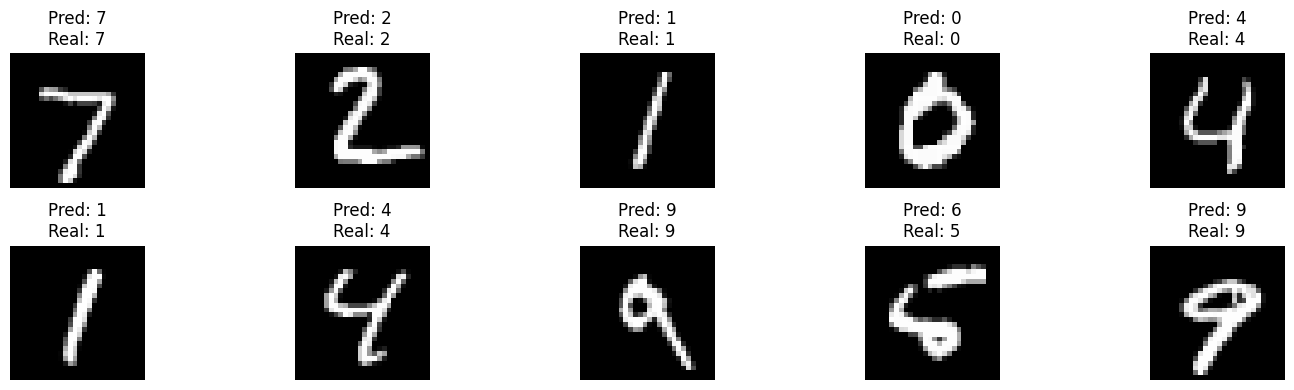

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Cargar y preprocesar
# =========================
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar a [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# =========================
# 2. Construir modelo MLP
# =========================
model_mlp = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model_mlp.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================
# 3. Entrenar
# =========================
history_mlp = model_mlp.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=32,
    verbose=1
)

# =========================
# 4. Evaluar en test
# =========================
test_loss_mlp, test_acc_mlp = model_mlp.evaluate(x_test, y_test, verbose=0)
print(f"\nMLP - Accuracy en test: {test_acc_mlp:.4f}")

# =========================
# 5. Gráficas de pérdida y accuracy
# =========================
plt.figure(figsize=(12, 5))

# Pérdida
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history["loss"], label="Train Loss")
plt.plot(history_mlp.history["val_loss"], label="Val Loss")
plt.title("MLP - Pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_mlp.history["accuracy"], label="Train Acc")
plt.plot(history_mlp.history["val_accuracy"], label="Val Acc")
plt.title("MLP - Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# =========================
# 6. Predicciones de ejemplo
# =========================
preds_mlp = model_mlp.predict(x_test)
pred_labels_mlp = np.argmax(preds_mlp, axis=1)

# Mostrar 10 ejemplos
plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"Pred: {pred_labels_mlp[i]}\nReal: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()